# RNN и Трансформеры
Нейросети для работы с последовательностями

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)

C:\Users\Ruslan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow: 2.20.0


---
# Часть 1: RNN (Рекуррентная сеть)
## Задача: Анализ тональности отзывов (позитив/негатив)

### Как работает RNN
```
Обычная сеть:     Вход → [Сеть] → Выход

RNN:              Слово1 → [Сеть] → состояние1
                              ↓
                  Слово2 → [Сеть] → состояние2  
                              ↓
                  Слово3 → [Сеть] → состояние3 → Выход
                  
RNN помнит предыдущие слова через "состояние"
```

In [2]:
# Загрузка датасета IMDB (отзывы на фильмы)
vocab_size = 10000  # размер словаря
max_length = 200    # максимальная длина отзыва

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

print(f'Обучающая выборка: {len(x_train)} отзывов')
print(f'Тестовая выборка: {len(x_test)} отзывов')
print(f'Классы: 0=негативный, 1=позитивный')
print(f'\nПример (числа = индексы слов):')
print(x_train[0][:20], '...')

C:\Users\Ruslan\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Обучающая выборка: 25000 отзывов
Тестовая выборка: 25000 отзывов
Классы: 0=негативный, 1=позитивный

Пример (числа = индексы слов):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...


In [3]:
# Декодируем пример обратно в текст
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded])

print('Пример отзыва:')
print(decode_review(x_train[0])[:300], '...')
print(f'\nМетка: {"позитивный" if y_train[0] else "негативный"}')

Пример отзыва:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there wa ...

Метка: позитивный


In [4]:
# Приводим все отзывы к одной длине (padding)
x_train_pad = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_length)
x_test_pad = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_length)

print('Форма данных:', x_train_pad.shape)

Форма данных: (25000, 200)


### Модель с LSTM (улучшенная RNN)

In [5]:
# LSTM модель
rnn_model = keras.Sequential([
    # Embedding: слово (число) → вектор 128 чисел
    layers.Embedding(vocab_size, 128, input_length=max_length),
    
    # LSTM: обрабатывает последовательность, помнит контекст
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    
    # Классификация
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # 0-1 (негатив-позитив)
])

rnn_model.summary()

C:\Users\Ruslan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Обучение (2 эпохи для демонстрации)
rnn_history = rnn_model.fit(
    x_train_pad, y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Оценка LSTM сразу после обучения
rnn_loss, rnn_acc = rnn_model.evaluate(x_test_pad, y_test, verbose=0)
print(f'\nТочность LSTM: {rnn_acc * 100:.2f}%')

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - accuracy: 0.7735 - loss: 0.4728 - val_accuracy: 0.8688 - val_loss: 0.3200
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.8959 - loss: 0.2754 - val_accuracy: 0.8482 - val_loss: 0.3491

Точность LSTM: 84.78%


In [7]:
# Блок Multi-Head Attention
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
    
    def call(self, inputs, training=None):  # training теперь опциональный
        # Self-Attention
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)  # Residual connection
        
        # Feed Forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)  # Residual connection

print('TransformerBlock создан')

TransformerBlock создан


---
# Часть 2: Трансформер
## Та же задача, но другая архитектура

### Как работает Трансформер
```
RNN:          Слово1 → Слово2 → Слово3 → Слово4 (последовательно)

Трансформер:  Слово1 ←→ Слово2 ←→ Слово3 ←→ Слово4 (все сразу!)
              
              Каждое слово "смотрит" на все остальные
              через механизм Attention (внимание)
```

### Self-Attention
```
Предложение: "Фильм был очень скучный"

Для слова "скучный" attention показывает:
  - "Фильм" → 0.4 (важно - про что речь)
  - "был"   → 0.1 (не важно)
  - "очень" → 0.3 (усиливает значение)
  - "скучный" → 0.2
```

In [8]:
# Блок Multi-Head Attention
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)
    
    def call(self, inputs, training=None):
        # Self-Attention
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)  # Residual connection
        
        # Feed Forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)  # Residual connection

print('TransformerBlock создан')

TransformerBlock создан


In [9]:
# Positional Embedding (позиция слова в предложении)
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = layers.Embedding(maxlen, embed_dim)
    
    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

print('TokenAndPositionEmbedding создан')

TokenAndPositionEmbedding создан


In [10]:
# Параметры трансформера
embed_dim = 64    # размер эмбеддинга
num_heads = 4     # количество "голов" внимания
ff_dim = 64       # размер feed-forward слоя

# Модель трансформера
inputs = layers.Input(shape=(max_length,))
embedding_layer = TokenAndPositionEmbedding(max_length, vocab_size, embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
x = transformer_block(x)
x = layers.GlobalAveragePooling1D()(x)  # усреднение по всем позициям
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

transformer_model = keras.Model(inputs=inputs, outputs=outputs)
transformer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 200, 64)        │       652,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 200, 64)        │        74,944 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 729,857 (2.78 MB)

 Trainable params: 729,857 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
transformer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Обучение трансформера
trans_history = transformer_model.fit(
    x_train_pad, y_train,
    epochs=2,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 107ms/step - accuracy: 0.7379 - loss: 0.4895 - val_accuracy: 0.8732 - val_loss: 0.3031
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.9068 - loss: 0.2461 - val_accuracy: 0.8774 - val_loss: 0.2975


In [12]:
# Оценка трансформера
trans_loss, trans_acc = transformer_model.evaluate(x_test_pad, y_test, verbose=0)

print(f'Точность Transformer: {trans_acc * 100:.2f}%')
print(f'Точность LSTM: {rnn_acc * 100:.2f}%')
print(f'\nTransformer лучше на {(trans_acc - rnn_acc) * 100:.2f}%' if trans_acc > rnn_acc else f'\nLSTM лучше на {(rnn_acc - trans_acc) * 100:.2f}%')

Точность Transformer: 87.49%
Точность LSTM: 84.78%

Transformer лучше на 2.71%


---
## Сравнение архитектур

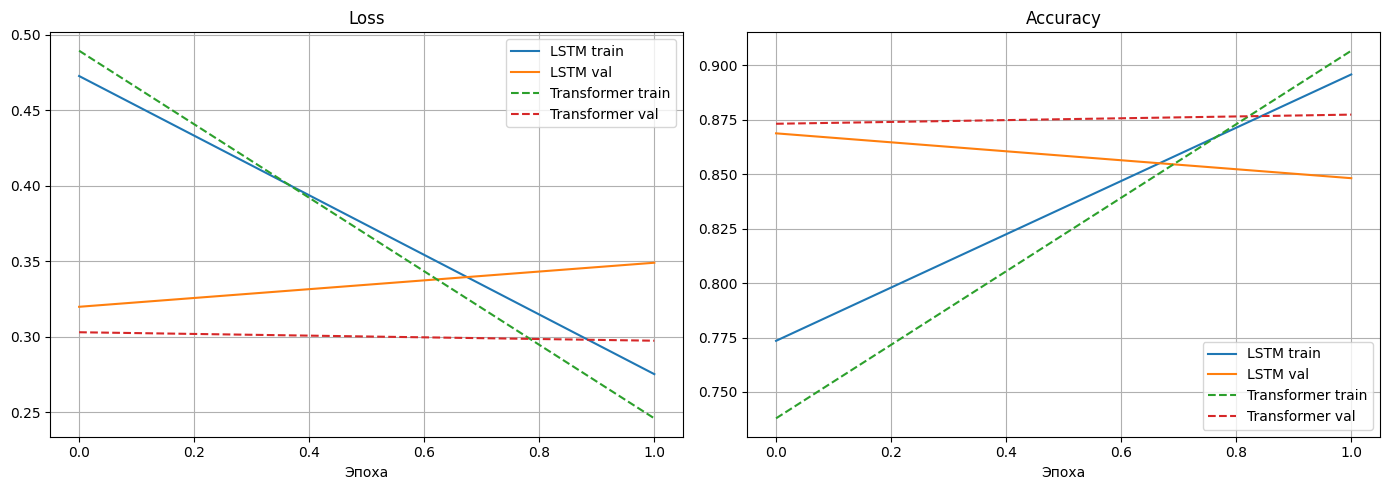

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(rnn_history.history['loss'], label='LSTM train')
axes[0].plot(rnn_history.history['val_loss'], label='LSTM val')
axes[0].plot(trans_history.history['loss'], label='Transformer train', linestyle='--')
axes[0].plot(trans_history.history['val_loss'], label='Transformer val', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Эпоха')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(rnn_history.history['accuracy'], label='LSTM train')
axes[1].plot(rnn_history.history['val_accuracy'], label='LSTM val')
axes[1].plot(trans_history.history['accuracy'], label='Transformer train', linestyle='--')
axes[1].plot(trans_history.history['val_accuracy'], label='Transformer val', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Эпоха')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Тестирование на своих отзывах

In [14]:
def predict_sentiment(text, model, word_index):
    """Предсказание тональности текста"""
    # Токенизация
    words = text.lower().split()
    encoded = [word_index.get(w, 2) + 3 for w in words]  # 2 = unknown
    
    # Padding
    padded = keras.preprocessing.sequence.pad_sequences([encoded], maxlen=max_length)
    
    # Предсказание
    pred = model.predict(padded, verbose=0)[0][0]
    
    sentiment = 'Позитивный' if pred > 0.5 else 'Негативный'
    confidence = pred if pred > 0.5 else 1 - pred
    
    return sentiment, confidence * 100

# Примеры
reviews = [
    "This movie was amazing! Great acting and wonderful story.",
    "Terrible film. Waste of time. Very boring and bad acting.",
    "Not bad, but not great either. Just an average movie."
]

print('=== LSTM ===' )
for review in reviews:
    sentiment, conf = predict_sentiment(review, rnn_model, word_index)
    print(f'{sentiment} ({conf:.1f}%): {review[:50]}...')

print('\n=== Transformer ===')
for review in reviews:
    sentiment, conf = predict_sentiment(review, transformer_model, word_index)
    print(f'{sentiment} ({conf:.1f}%): {review[:50]}...')

=== LSTM ===
Позитивный (90.8%): This movie was amazing! Great acting and wonderful...
Негативный (97.3%): Terrible film. Waste of time. Very boring and bad ...
Позитивный (62.1%): Not bad, but not great either. Just an average mov...

=== Transformer ===
Позитивный (99.4%): This movie was amazing! Great acting and wonderful...
Негативный (99.9%): Terrible film. Waste of time. Very boring and bad ...
Позитивный (86.8%): Not bad, but not great either. Just an average mov...


---
## Визуализация Attention (внимания)

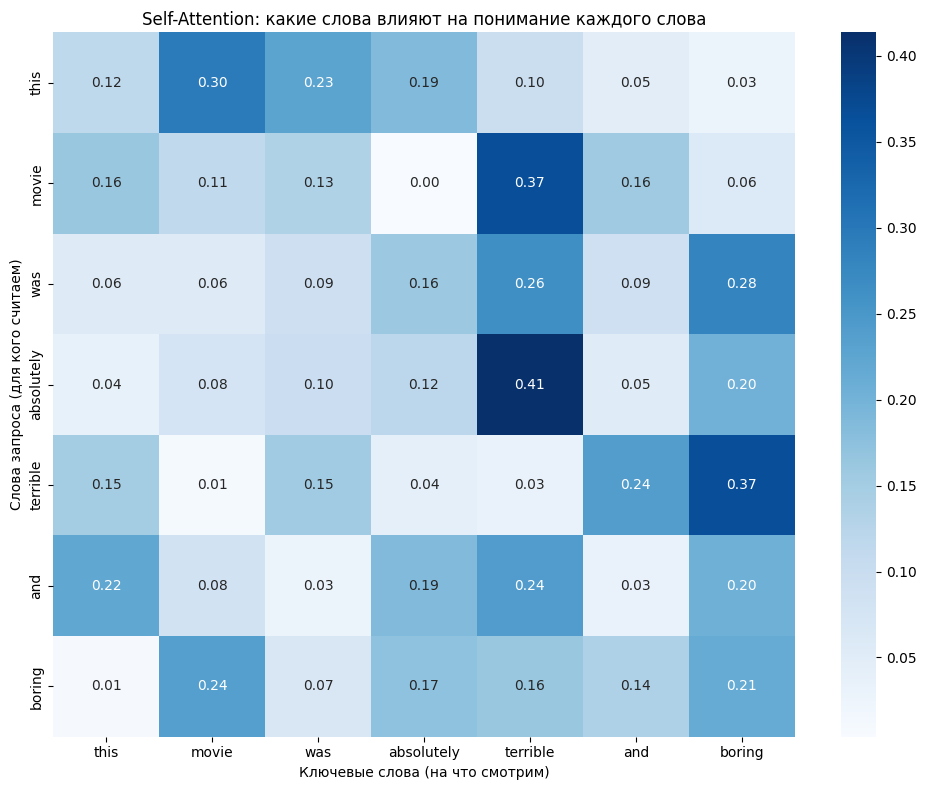


Интерпретация:
• Каждая строка показывает, на какие слова "смотрит" данное слово
• Высокие значения = сильное влияние
• "terrible" и "boring" получают больше внимания - они определяют тональность


In [15]:
# Визуализация того, как работает Attention (схематично)
import seaborn as sns

# Пример текста
sample_text = "this movie was absolutely terrible and boring"
words = sample_text.split()

# Симулируем attention weights (для демонстрации)
# В реальности они вычисляются моделью
np.random.seed(42)
n_words = len(words)
attention_weights = np.random.rand(n_words, n_words)
attention_weights = attention_weights / attention_weights.sum(axis=1, keepdims=True)

# Делаем "terrible" и "boring" более важными для негативной классификации
attention_weights[:, 4] *= 2  # terrible
attention_weights[:, 6] *= 1.5  # boring
attention_weights = attention_weights / attention_weights.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(attention_weights, xticklabels=words, yticklabels=words, 
            annot=True, fmt='.2f', cmap='Blues')
plt.title('Self-Attention: какие слова влияют на понимание каждого слова')
plt.xlabel('Ключевые слова (на что смотрим)')
plt.ylabel('Слова запроса (для кого считаем)')
plt.tight_layout()
plt.show()

print('\nИнтерпретация:')
print('• Каждая строка показывает, на какие слова "смотрит" данное слово')
print('• Высокие значения = сильное влияние')
print('• "terrible" и "boring" получают больше внимания - они определяют тональность')

---
## Итоговое сравнение

In [16]:
comparison = """
┌─────────────────┬──────────────────┬──────────────────┐
│                 │      RNN/LSTM    │   Transformer    │
├─────────────────┼──────────────────┼──────────────────┤
│ Обработка       │ Последовательно  │ Параллельно      │
│ Память          │ Ограничена       │ Вся seq сразу    │
│ Скорость        │ Медленнее        │ Быстрее (GPU)    │
│ Длинные тексты  │ Плохо            │ Хорошо           │
│ Применение      │ Временные ряды   │ NLP, GPT, BERT   │
└─────────────────┴──────────────────┴──────────────────┘

Трансформеры - основа современных моделей:
• GPT (ChatGPT) - генерация текста
• BERT - понимание текста  
• ViT - компьютерное зрение
• Whisper - распознавание речи
"""
print(comparison)


┌─────────────────┬──────────────────┬──────────────────┐
│                 │      RNN/LSTM    │   Transformer    │
├─────────────────┼──────────────────┼──────────────────┤
│ Обработка       │ Последовательно  │ Параллельно      │
│ Память          │ Ограничена       │ Вся seq сразу    │
│ Скорость        │ Медленнее        │ Быстрее (GPU)    │
│ Длинные тексты  │ Плохо            │ Хорошо           │
│ Применение      │ Временные ряды   │ NLP, GPT, BERT   │
└─────────────────┴──────────────────┴──────────────────┘

Трансформеры - основа современных моделей:
• GPT (ChatGPT) - генерация текста
• BERT - понимание текста  
• ViT - компьютерное зрение
• Whisper - распознавание речи

